In [1]:
import pandas as pd
import numpy as np

# 1. Carregar a telemetria simulada do satélite
# O '../' volta uma pasta para sair de 'notebooks' e entrar em 'data'
df = pd.read_csv('../data/safeorbit_telemetry.csv')

# Visualizar as 5 primeiras linhas para garantir que o schema está correto
df.head()

,id_alerta,latitude,longitude,altitude_m,temperatura_c,clima,bateria_beacon_pct,frequencia_cardiaca_bpm,idade_usuario,tipo_terreno,prioridade_resgate
0,SOS-0001,-22.58278,-113.35215,1243,23.7,Ceu_Limpo,72,84,46,Corpo_D_Agua,Media
1,SOS-0002,81.12858,15.08434,4998,-17.0,Nevasca,51,68,28,Pico_Nevado,Critica
2,SOS-0003,41.75891,134.26050,162,25.0,Neblina,20,140,33,Corpo_D_Agua,Critica
3,SOS-0004,17.75853,83.60096,1974,19.7,Ceu_Limpo,96,99,47,Corpo_D_Agua,Baixa
4,SOS-0005,-61.91664,110.36201,3291,-7.6,Nevasca,86,124,42,Pico_Nevado,Media


In [2]:
# 2. Separar as variáveis preditoras (X) do nosso alvo (y)
# O id_alerta é inútil para prever o risco, então o descartamos da matriz X
X = df.drop(columns=['id_alerta', 'prioridade_resgate'])
y = df['prioridade_resgate']

# 3. Aplicar One-Hot Encoding nas colunas de texto
# drop_first=True evita a armadilha da multicolinearidade
X_encoded = pd.get_dummies(X, columns=['clima', 'tipo_terreno'], drop_first=True)

print(f"Shape original de X: {X.shape}")
print(f"Shape de X após encoding: {X_encoded.shape}")

# Visualizar a nova matriz matemática pronta para o modelo
X_encoded.head()

Shape original de X: (1000, 9)
Shape de X após encoding: (1000, 14)


,latitude,longitude,altitude_m,temperatura_c,bateria_beacon_pct,frequencia_cardiaca_bpm,idade_usuario,clima_Chuva_Forte,clima_Neblina,clima_Nevasca,tipo_terreno_Deserto,tipo_terreno_Floresta_Densa,tipo_terreno_Montanha_Rochosa,tipo_terreno_Pico_Nevado
0,-22.58278,-113.35215,1243,23.7,72,84,46,False,False,False,False,False,False,False
1,81.12858,15.08434,4998,-17.0,51,68,28,False,False,True,False,False,False,True
2,41.75891,134.26050,162,25.0,20,140,33,False,True,False,False,False,False,False
3,17.75853,83.60096,1974,19.7,96,99,47,False,False,False,False,False,False,False
4,-61.91664,110.36201,3291,-7.6,86,124,42,False,False,True,False,False,False,True


========== RESULTADOS RANDOM FOREST ==========
              precision    recall  f1-score   support

       Baixa       0.88      0.91      0.89        23
       Media       0.87      0.96      0.91        77
        Alta       0.93      0.76      0.84        17
     Critica       1.00      0.93      0.96        83

    accuracy                           0.93       200
   macro avg       0.92      0.89      0.90       200
weighted avg       0.93      0.93      0.93       200


========== RESULTADOS XGBOOST ==========
              precision    recall  f1-score   support

       Baixa       0.88      0.91      0.89        23
       Media       0.97      0.96      0.97        77
        Alta       0.94      1.00      0.97        17
     Critica       1.00      0.99      0.99        83

    accuracy                           0.97       200
   macro avg       0.95      0.97      0.96       200
weighted avg       0.97      0.97      0.97       200



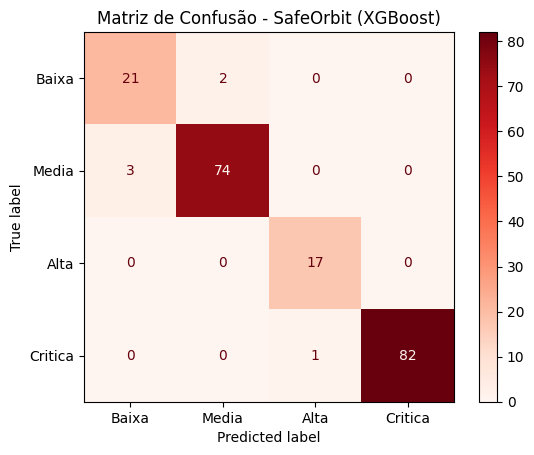

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Separar Treino (80%) e Teste (20%) - O stratify garante que todas as classes sejam bem representadas
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# 2. Preparação: O XGBoost moderno exige que o nosso "alvo" (y) seja numérico, e não texto
mapa_classes = {'Baixa': 0, 'Media': 1, 'Alta': 2, 'Critica': 3}
y_train_num = y_train.map(mapa_classes)
y_test_num = y_test.map(mapa_classes)

# 3. Treinar o Random Forest (Nosso modelo Baseline)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train_num)
rf_pred = rf.predict(X_test)

# 4. Treinar o XGBoost (O nosso motor principal de alta performance)
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train_num)
xgb_pred = xgb_model.predict(X_test)

# 5. Imprimir o Boletim de Notas (Classification Report)
print("========== RESULTADOS RANDOM FOREST ==========")
print(classification_report(y_test_num, rf_pred, target_names=['Baixa', 'Media', 'Alta', 'Critica']))

print("\n========== RESULTADOS XGBOOST ==========")
print(classification_report(y_test_num, xgb_pred, target_names=['Baixa', 'Media', 'Alta', 'Critica']))

# 6. Plotar a Matriz de Confusão do XGBoost (Onde vemos os acertos e os erros fatais)
cm = confusion_matrix(y_test_num, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baixa', 'Media', 'Alta', 'Critica'])
disp.plot(cmap='Reds')
plt.title("Matriz de Confusão - SafeOrbit (XGBoost)")
plt.show()

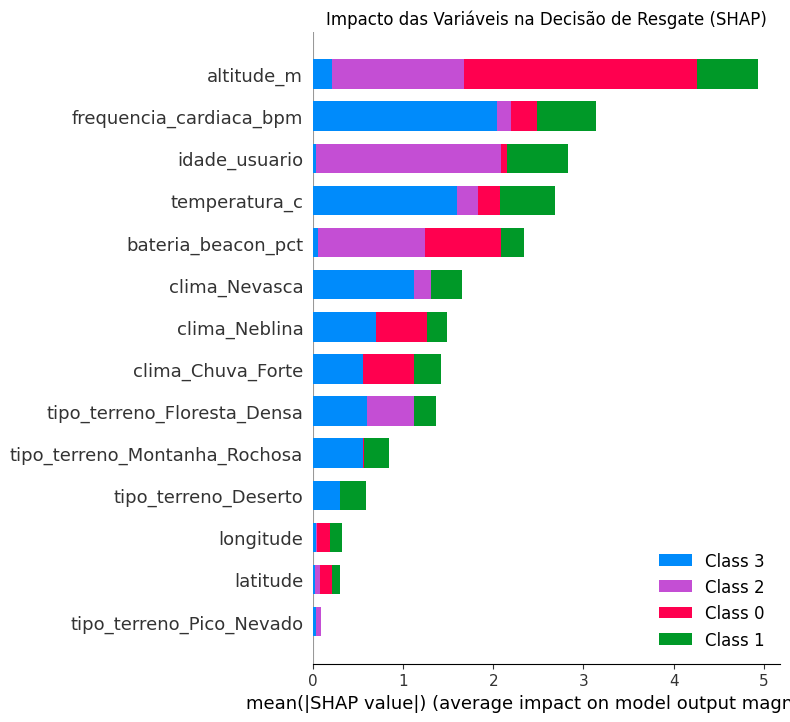

In [5]:
import shap

# 1. Inicializar os scripts do SHAP para exibir gráficos bonitos no Notebook
shap.initjs()

# 2. Criar o explicador matemático focado no nosso modelo campeão (XGBoost)
explainer = shap.TreeExplainer(xgb_model)

# 3. Calcular o peso (impacto) de cada variável nas decisões
shap_values = explainer.shap_values(X_test)

# 4. Plotar o Gráfico de Importância Global
# Ele vai criar uma barra colorida para cada variável, mostrando o impacto dela
# em cada uma das 4 classes (Baixa, Media, Alta, Critica)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

# Ajuste simples de título para ficar bonito no print do README do GitHub
import matplotlib.pyplot as plt
plt.title("Impacto das Variáveis na Decisão de Resgate (SHAP)")
plt.show()

In [6]:
import joblib
import os

# Garantir que a pasta app existe
os.makedirs('../app', exist_ok=True)

# Salvar o modelo treinado
joblib.dump(xgb_model, '../app/safeorbit_xgboost.pkl')

# Salvar a lista exata de colunas para o Streamlit saber montar a matriz
joblib.dump(list(X_encoded.columns), '../app/colunas_modelo.pkl')

print("Modelo e colunas exportados com sucesso para a pasta 'app'!")

Modelo e colunas exportados com sucesso para a pasta 'app'!
